# Feature Selection and data splitting

In [72]:
import pandas as pd, numpy as np, json
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
import xgboost as xgb, shap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [73]:
df = pd.read_parquet("../data/processed/final/address_level_fused.parquet")
meta = json.load(open('../../models/address_features_metadata.json'))

ALL_FEATURES = meta['onchain_features'] + meta['market_features'] + meta['reddit_features'] + meta['twitter_features']

TARGET = 'is_scam'

### Train / Test splitting

In [74]:
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")
print(f"Train scam ratio: {y_train.mean():.2%}")
print(f"Test scam ratio:  {y_test.mean():.2%}")

Train size: 28217  Test size: 7055
Train scam ratio: 16.28%
Test scam ratio:  16.27%


### SHAP Feature Importance

In [75]:
model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
)

model.fit(X_train, y_train)

# compute SHAP feature importance
importance = pd.Series(
    np.abs(shap.TreeExplainer(model).shap_values(X_train)).mean(0), index=ALL_FEATURES
).sort_values(ascending=False)

# cumulative importance
cumsum = importance.cumsum() / importance.sum()

print(f"{'Cutoff':<8} {'Features':>8} {'Test F1':>8} {'AUC':>8}")

# compare different cutoffs
for pct in [0.95, 0.90, 0.85, 0.80]:
    # select features
    k = cumsum[cumsum <= pct].index.tolist()
    if len(k) < len(cumsum): k.append(cumsum.index[len(k)])

    m = xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
    )

    # train model using selected features
    m.fit(X_train[k], y_train)

    # evaluate each model
    p = m.predict_proba(X_test[k])[:, 1]
    y_pred = (p >= 0.5).astype(int)

    print(f"{int(pct*100):<6} {len(k):>8} {f1_score(y_test, y_pred):>10.4f} {roc_auc_score(y_test, p):>10.4f}")

Cutoff   Features  Test F1      AUC
95           54     0.8347     0.9596
90           46     0.8293     0.9615
85           40     0.8335     0.9597
80           34     0.8366     0.9598


### Final Feature Selection

In [76]:
keep = cumsum[cumsum <= 0.80].index.tolist()
if len(keep) < len(cumsum):
    keep.append(cumsum.index[len(keep)])

onchain = [f for f in keep if not any(f.startswith(p) for p in ['market_','reddit_','twitter_'])]
market = [f for f in keep if f.startswith('market_')]
reddit = [f for f in keep if f.startswith('reddit_')]
twitter = [f for f in keep if f.startswith('twitter_')]

print(f"\nFinal: {len(keep)} features (On-chain:{len(onchain)} Market:{len(market)} Reddit:{len(reddit)} Twitter:{len(twitter)})")


Final: 34 features (On-chain:19 Market:3 Reddit:5 Twitter:7)


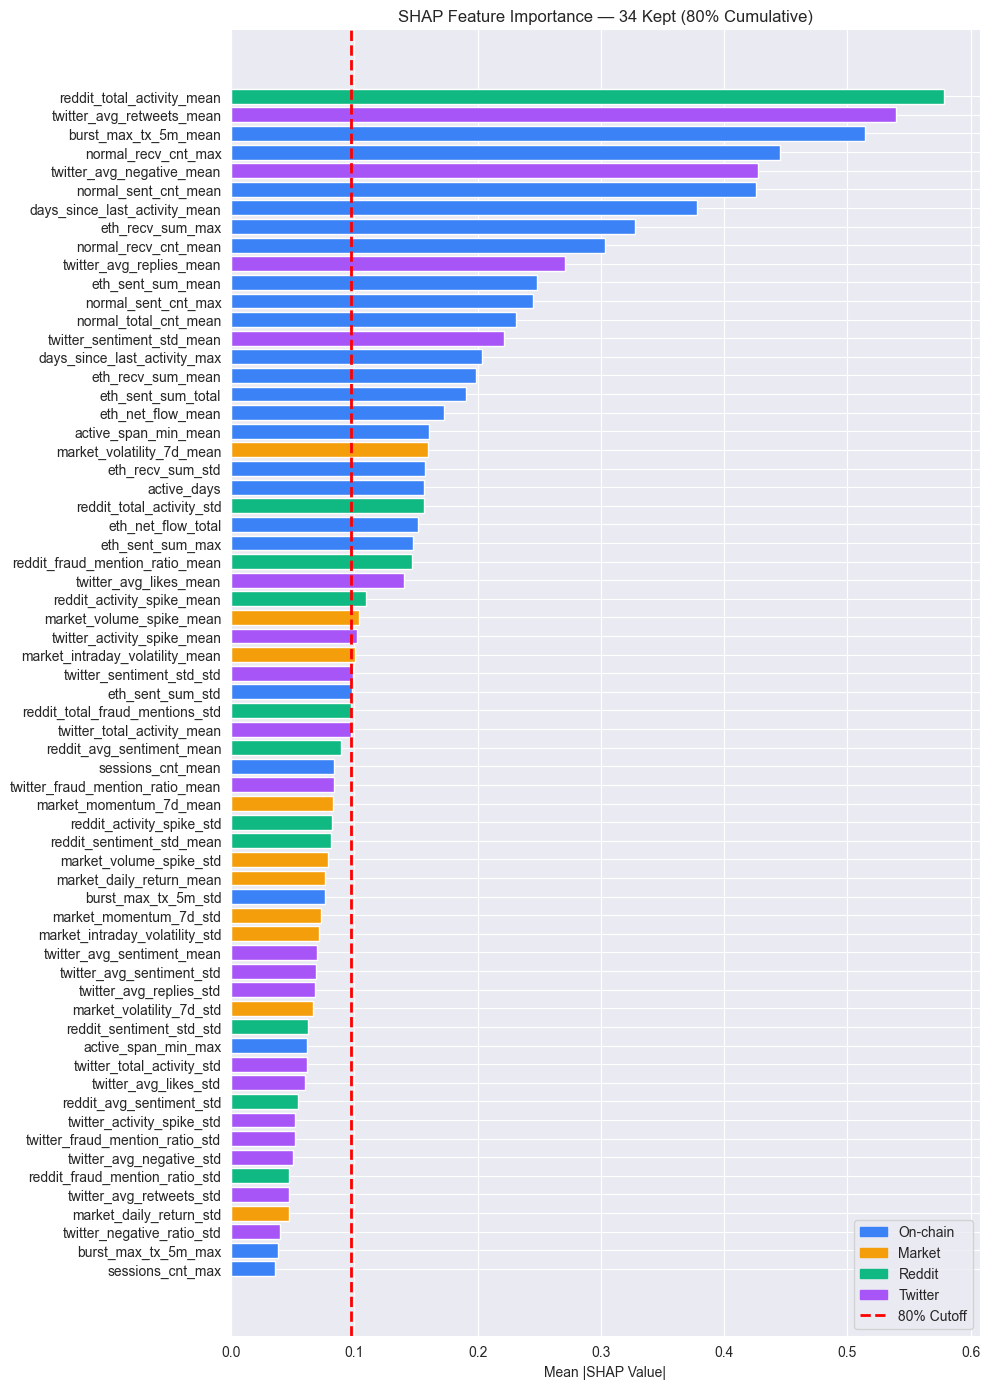

In [77]:
# color mapping
def get_color(f):
    if f.startswith('market_'): return '#f59e0b'
    if f.startswith('reddit_'): return '#10b981'
    if f.startswith('twitter_'): return '#a855f7'
    return '#3b82f6'

colors = [get_color(f) for f in importance.index]

cutoff_value = importance[keep[-1]] if keep else 0

# plot
plt.figure(figsize=(10, 14))
plt.barh(importance.index, importance.values, color=colors)

plt.axvline(cutoff_value, color='red', linestyle='--', linewidth=2)

plt.xlabel("Mean |SHAP Value|")
plt.title(f"SHAP Feature Importance — {len(keep)} Kept (80% Cumulative)")
plt.gca().invert_yaxis()

# legend
plt.legend(handles=[
    Patch(color='#3b82f6', label='On-chain'),
    Patch(color='#f59e0b', label='Market'),
    Patch(color='#10b981', label='Reddit'),
    Patch(color='#a855f7', label='Twitter'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='80% Cutoff')
], loc='lower right')

plt.tight_layout()
plt.show()

In [78]:
cols = ['address', 'is_scam'] + keep

train_df = df.loc[X_train.index, cols]
train_df.to_parquet("../data/processed/final/train_set.parquet", index=False)

test_df = df.loc[X_test.index, cols]
test_df.to_parquet("../data/processed/final/test_set.parquet", index=False)

metadata = {
    'onchain_features': onchain,
    'market_features': market,
    'reddit_features': reddit,
    'twitter_features': twitter
}

with open('../../models/address_features_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Saved")

Saved
